In [32]:
import sys
print(sys.executable)

c:\Users\irina\OneDrive\Desktop\Tweet_Emotion_Recognition\venv\Scripts\python.exe


In [33]:
import tensorflow as tf
import numpy as np
import pandas as pd
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [34]:
from datasets import load_dataset


In [35]:
dataset = load_dataset("dair-ai/emotion")

In [36]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [37]:
print(dataset["train"][0])

{'text': 'i didnt feel humiliated', 'label': 0}


In [38]:
class_names = dataset["train"].features["label"].names
print(class_names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [39]:
for i in range(5):
    example = dataset["train"][i]
    emotion = class_names[example["label"]]
    print(f"{emotion}: {example['text']}")

sadness: i didnt feel humiliated
sadness: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
anger: im grabbing a minute to post i feel greedy wrong
love: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
anger: i am feeling grouchy


In [40]:
train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]

val_texts = dataset["validation"]["text"]
val_labels = dataset["validation"]["label"]

test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

In [41]:
import numpy as np

train_labels = np.array(train_labels)
val_labels = np.array(val_labels)
test_labels = np.array(test_labels)

In [42]:
VOCAB_SIZE = 10000
OOV_TOKEN = "<OOV>"

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_texts)

In [43]:
word_index = tokenizer.word_index
print("Total unique words found:", len(word_index))
print("Sample mappings:", dict(list(word_index.items())[:10]))

Total unique words found: 15213
Sample mappings: {'<OOV>': 1, 'i': 2, 'feel': 3, 'and': 4, 'to': 5, 'the': 6, 'a': 7, 'feeling': 8, 'that': 9, 'of': 10}


In [44]:
train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

print("Original tweet:", train_texts[0])
print("As a sequence:", train_sequences[0])

Original tweet: i didnt feel humiliated
As a sequence: [2, 139, 3, 679]


In [45]:
lengths = [len(seq) for seq in train_sequences]

print("Shortest tweet:", min(lengths))
print("Longest tweet:", max(lengths))
print("Median length:", int(np.median(lengths)))
print("95th percentile length:", int(np.percentile(lengths, 95)))

Shortest tweet: 2
Longest tweet: 66
Median length: 17
95th percentile length: 41


In [46]:
MAXLEN = 50

In [47]:
train_padded = tf.keras.preprocessing.sequence.pad_sequences(
    train_sequences, maxlen=MAXLEN, padding="post", truncating="post"
)
val_padded = tf.keras.preprocessing.sequence.pad_sequences(
    val_sequences, maxlen=MAXLEN, padding="post", truncating="post"
)
test_padded = tf.keras.preprocessing.sequence.pad_sequences(
    test_sequences, maxlen=MAXLEN, padding="post", truncating="post"
)

In [48]:
print("Padded shape:", train_padded.shape)
print("Example padded tweet:", train_padded[0])

Padded shape: (16000, 50)
Example padded tweet: [  2 139   3 679   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [49]:
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Classes:", class_names)

Number of classes: 6
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [50]:
EMBEDDING_DIM = 16

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAXLEN),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20)),
    tf.keras.layers.Dense(24, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

In [51]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [52]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

In [54]:
history = model.fit(
    train_padded, train_labels,
    validation_data=(val_padded, val_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.4232 - loss: 1.4248 - val_accuracy: 0.7090 - val_loss: 0.8770
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7691 - loss: 0.6750 - val_accuracy: 0.8100 - val_loss: 0.5749
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.8745 - loss: 0.3979 - val_accuracy: 0.8385 - val_loss: 0.4756
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.9128 - loss: 0.2743 - val_accuracy: 0.8680 - val_loss: 0.4394
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9351 - loss: 0.2127 - val_accuracy: 0.8825 - val_loss: 0.4193
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9502 - loss: 0.1759 - val_accuracy: 0.8805 - val_loss: 0.4129
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9589 - loss: 0.1428 - val_accuracy: 0.8875 - val_loss: 0.4070
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.9621 - loss: 0.1336 - 

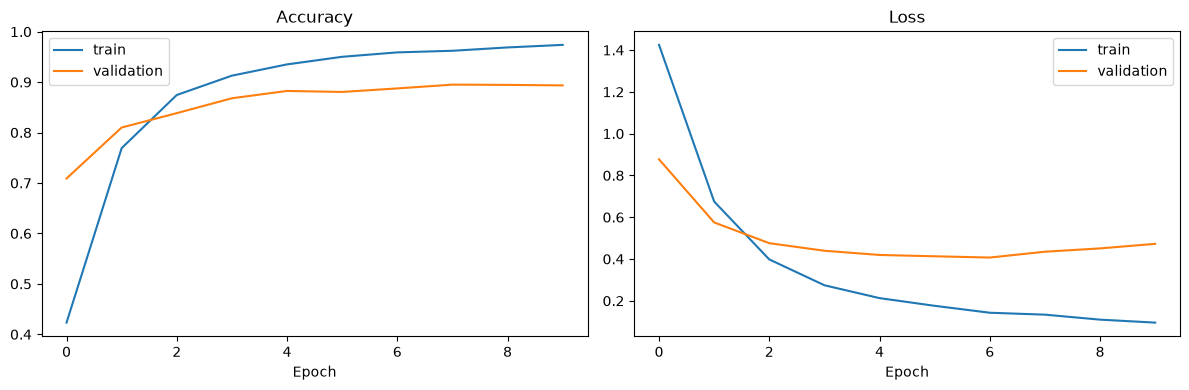

In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [56]:
test_loss, test_acc = model.evaluate(test_padded, test_labels)
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test loss: {test_loss:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8790 - loss: 0.4098
Test accuracy: 0.879
Test loss: 0.410


In [57]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [58]:
predictions = model.predict(test_padded)
predicted_labels = np.argmax(predictions, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step


In [59]:
print(classification_report(test_labels, predicted_labels, target_names=class_names))

              precision    recall  f1-score   support

     sadness       0.98      0.90      0.93       581
         joy       0.92      0.90      0.91       695
        love       0.72      0.79      0.75       159
       anger       0.84      0.88      0.86       275
        fear       0.81      0.87      0.84       224
    surprise       0.59      0.71      0.64        66

    accuracy                           0.88      2000
   macro avg       0.81      0.84      0.82      2000
weighted avg       0.89      0.88      0.88      2000



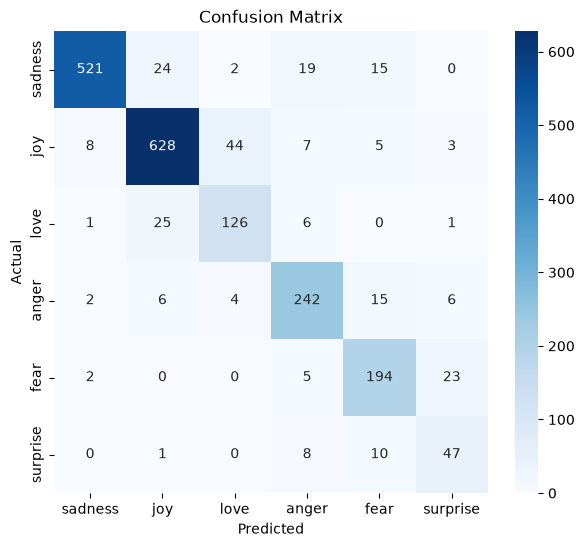

In [60]:
cm = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [61]:
def predict_emotion(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=MAXLEN, padding="post", truncating="post")
    pred = model.predict(padded, verbose=0)[0]
    idx = np.argmax(pred)
    return class_names[idx], float(pred[idx])

In [62]:
sample_tweets = [
    "I can't believe how amazing today turned out to be",
    "I am so tired of everything going wrong",
    "I miss my best friend so much",
    "That movie completely terrified me",
]

for t in sample_tweets:
    label, confidence = predict_emotion(t)
    print(f"{t!r} -> {label} ({confidence:.2f})")

"I can't believe how amazing today turned out to be" -> fear (0.82)
'I am so tired of everything going wrong' -> sadness (0.81)
'I miss my best friend so much' -> anger (0.71)
'That movie completely terrified me' -> fear (0.98)


In [63]:
model.save("tweet_emotion_model.keras")

In [64]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [65]:
loaded_model = tf.keras.models.load_model("tweet_emotion_model.keras")

with open("tokenizer.pkl", "rb") as f:
    loaded_tokenizer = pickle.load(f)

print("Model and tokenizer loaded successfully.")

Model and tokenizer loaded successfully.


In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [67]:
tfidf = TfidfVectorizer(max_features=10000)

train_tfidf = tfidf.fit_transform(train_texts)
val_tfidf = tfidf.transform(val_texts)
test_tfidf = tfidf.transform(test_texts)

print("TF-IDF matrix shape:", train_tfidf.shape)

TF-IDF matrix shape: (16000, 10000)


In [68]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(train_tfidf, train_labels)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [69]:
baseline_predictions = baseline_model.predict(test_tfidf)

print(classification_report(test_labels, baseline_predictions, target_names=class_names))

              precision    recall  f1-score   support

     sadness       0.89      0.93      0.91       581
         joy       0.84      0.96      0.89       695
        love       0.82      0.58      0.68       159
       anger       0.90      0.82      0.86       275
        fear       0.88      0.78      0.83       224
    surprise       0.84      0.48      0.62        66

    accuracy                           0.86      2000
   macro avg       0.86      0.76      0.80      2000
weighted avg       0.87      0.86      0.86      2000



In [70]:
comparison = pd.DataFrame({
    "Model": ["Bidirectional LSTM", "TF-IDF + Logistic Regression"],
    "Test Accuracy": [test_acc, baseline_model.score(test_tfidf, test_labels)],
})
print(comparison)

                          Model  Test Accuracy
0            Bidirectional LSTM         0.8790
1  TF-IDF + Logistic Regression         0.8645


In [71]:
model.save("tweet_emotion_model.keras")

In [72]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [73]:
loaded_model = tf.keras.models.load_model("tweet_emotion_model.keras")

with open("tokenizer.pkl", "rb") as f:
    loaded_tokenizer = pickle.load(f)

print("Model and tokenizer loaded successfully.")

Model and tokenizer loaded successfully.
